In [7]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

# Step 2: URL
url = "https://old.reddit.com/r/WegovyWeightLoss/"

# Step 3: Headers
headers = {
    "user-agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# Step 4: GET Request
response = requests.get(url, headers=headers)
print("Status code:", response.status_code)

# Step 5: Parse HTML
if response.status_code == 200:
    soup = BeautifulSoup(response.text, "html.parser")
    print("Page parsed successfully.")
else:
    print("Failed to retrieve page.")

# Step 6: Extract Thread Links
thread_links = []

for tag in soup.find_all("a", attrs={"data-event-action": "comments"}):
    link = tag["href"]
    if link.startswith("/"):
        link = "https://old.reddit.com" + link
    thread_links.append(link)
    print(link)

print(f"\nTotal threads found: {len(thread_links)}")

# Step 7: Initialize Data Storage
threads_data = []

# Step 8: Extract Data from Each Thread
for i, link in enumerate(thread_links, start=1):
    print(f"Scraping thread {i}/{len(thread_links)}: {link}")

    try:
        thread_response = requests.get(link, headers=headers)

        if thread_response.status_code != 200:
            print(f"  -> Failed (status {thread_response.status_code}), skipping.")
            continue

        thread_soup = BeautifulSoup(thread_response.text, "html.parser")

        # Title
        title_tag = thread_soup.find("a", class_="title")
        title = title_tag.get_text(strip=True) if title_tag else "N/A"

        # Content
        content_tag = thread_soup.find("div", class_="expando")
        content = content_tag.get_text(separator=" ", strip=True) if content_tag else "N/A"

        # Comments
        comments_tag = thread_soup.find("a", attrs={"data-event-action": "comments"})
        if comments_tag:
            comments_text = comments_tag.get_text(strip=True)
            comments = comments_text.split()[0] if comments_text else "0"
        else:
            comments = "0"

        # Upvotes
        upvotes_tag = (
            thread_soup.find("div", class_="score unvoted") or
            thread_soup.find("div", class_="score likes")
        )
        upvotes = upvotes_tag.get_text(strip=True) if upvotes_tag else "N/A"

        # Posted Date
        time_tag = thread_soup.find("time")
        posted_date = time_tag["datetime"] if time_tag and time_tag.has_attr("datetime") else "N/A"

        # Append to list
        threads_data.append({
            "Title":       title,
            "Content":     content,
            "Comments":    comments,
            "Upvotes":     upvotes,
            "Posted Date": posted_date,
            "URL":         link
        })

        print(f"  -> OK: {title[:60]}...")
        time.sleep(2)

    except Exception as e:
        print(f"  -> Error: {e}")

print(f"\nDone. {len(threads_data)} threads scraped successfully.")

# Step 9: Convert to DataFrame
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 300)

df = pd.DataFrame(threads_data)
print(df.shape)
df



Status code: 200
Page parsed successfully.
https://old.reddit.com/r/WegovyWeightLoss/comments/1f0jcd1/bans_will_begin_for_violating_the_nsfw_tag_rule/
https://old.reddit.com/r/WegovyWeightLoss/comments/11a7vy6/this_medication_takes_time_to_work/
https://old.reddit.com/r/WegovyWeightLoss/comments/1tsyk9e/100_pounds_lost_2_years_8_months/
https://old.reddit.com/r/WegovyWeightLoss/comments/1tszh57/sometimes_i_just_have_to_remind_myself_of_how_far/
https://old.reddit.com/r/WegovyWeightLoss/comments/1tscqlk/update_i_study_glp1s_for_a_living_and_finally/
https://old.reddit.com/r/WegovyWeightLoss/comments/1tsyegb/finally/
https://old.reddit.com/r/WegovyWeightLoss/comments/1ts5exw/6_months_in/
https://old.reddit.com/r/WegovyWeightLoss/comments/1trzp2h/wear_the_red_dress/
https://old.reddit.com/r/WegovyWeightLoss/comments/1tszr7e/realistic_weight_loss/
https://old.reddit.com/r/WegovyWeightLoss/comments/1tt0mdy/wegovy_5_has_me_feeling_bad_for_a_few_days_after/
https://old.reddit.com/r/WegovyWeig

,Title,Content,Comments,Upvotes,Posted Date,URL
0,Bans will begin for violating the NSFW tag rule.,"Hey folks. There have been a lot of reported posts lately for people posting underwear/swimwear progress photos without the NSFW tag. This is meant to be a place where people can find support throughout the day, not just outside business hours. If you're going to post NSFW progress photos, ta...",67,195,2024-08-25T00:01:34+00:00,https://old.reddit.com/r/WegovyWeightLoss/comments/1f0jcd1/bans_will_begin_for_violating_the_nsfw_tag_rule/
1,This medication takes time to work.,"Hey folks. In the last couple weeks there has been a significant number of ""I'm on .25mg and I'm disappointed"" posts. I just want to call out that .25mg is considered below the therapeutic threshold. Some people do feel a difference, but most people will not. Beyond that, Wegovy has a half l...",520,895,2023-02-23T20:31:18+00:00,https://old.reddit.com/r/WegovyWeightLoss/comments/11a7vy6/this_medication_takes_time_to_work/
2,"100 pounds lost! 2 years, 8 months!","Previous Next Back to Grid View Previous Next Back to Grid View Previous Next Back to Grid View 37, female, 5'6, PCOS. 260->160 It hasn't been easy. I've had to work really hard. I spend so much time in the gym or exercising. I weigh myself everyday and take me measurements once a week. I puked ...",10,•,2026-05-31T15:33:54+00:00,https://old.reddit.com/r/WegovyWeightLoss/comments/1tsyk9e/100_pounds_lost_2_years_8_months/
3,Sometimes I just have to remind myself of how far I've come,"Previous Next Back to Grid View Previous Next Back to Grid View 80lbs down in 2 1/2 years, 20lbs to go! Even though I didn't reach my goal within my time frame (2 years), I still am so proud of how far I've come and what a difference it has made to my life.",12,•,2026-05-31T16:08:31+00:00,https://old.reddit.com/r/WegovyWeightLoss/comments/1tszh57/sometimes_i_just_have_to_remind_myself_of_how_far/
4,"UPDATE: I study GLP-1s for a living and finally started the Wegovy myself: 5 Months, 50 lbs down + lessons learned as both a scientist and a patient",I study GLP-1s for a living and I've now lost 50 lbs on the Wegovy pill: Lessons I've learned as both a scientist and a patient If you want to read my original post its here: https://www.reddit.com/r/WegovyWeightLoss/comments/1qwup1m/i_study_glp1s_for_a_living_and_finally_started/ Disclaimer: Th...,141,296,2026-05-30T21:56:12+00:00,https://old.reddit.com/r/WegovyWeightLoss/comments/1tscqlk/update_i_study_glp1s_for_a_living_and_finally/
5,Finally…..,"I started taking 1.5mg on 4/1/26, upgraded to 4mg 5/1/26 and FINALLY hit a 10Lb loss after 2 months!!! I wish I can lose more a bit faster but 10lbs is 10lbs!!",2,•,2026-05-31T15:27:43+00:00,https://old.reddit.com/r/WegovyWeightLoss/comments/1tsyegb/finally/
6,6 months in!,"Today marks my 6 months on Wegovy! I am at 1.7 dose, second month on it. My starting weight was 205lbs, today I weighed in at 172! I am 5’1” and 25 years old. —33 pounds. I feel wonderful. I have had no major side effects and nausea/fatigue has gotten better overtime. I am not counting calories ...",10,309,2026-05-30T17:05:18+00:00,https://old.reddit.com/r/WegovyWeightLoss/comments/1ts5exw/6_months_in/
7,Wear the red dress,"I started Wegovy in August 2024. The picture on the left shows me at 238lbs, the pic on the right is from March 2026, when I weighed 175lbs. Currently I weigh 170, at my heaviest I weighed 250, so I’ve lost a total of 75lbs. My goals are to continue to lose fat and tone muscle. I have no intenti...",14,357,2026-05-30T13:15:45+00:00,https://old.reddit.com/r/WegovyWeightLoss/comments/1trzp2h/wear_the_red_dress/
8,Realistic weight loss?,"I start 0.25mg WeGovy this week I’m currently 5 foot and 67kg (quite overweight because of my height) size 14 I have a wedding to attend at the end of July, realistically will i have lost much weight by then from injections and eating less alone? Thank you! Goal weight is to get back to my pre p...",5,•,2026-05-31T

In [9]:
pip install vaderSentiment


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:

# ── Sentiment Analysis using VADER ──────────────────────────────
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Create the analyzer
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    """
    Takes a text string and returns:
    - 'Positive' if compound score >= 0.05
    - 'Negative' if compound score <= -0.05
    - 'Neutral'  otherwise
    """
    if text == 'N/A' or not text:
        return 'N/A'

    score = analyzer.polarity_scores(text)
    compound = score['compound']  # ranges from -1 (most negative) to +1 (most positive)

    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment to every row in the Content column
df['Sentiment'] = df['Content'].apply(get_sentiment)

# Show results
print("Sentiment Distribution:")
print(df['Sentiment'].value_counts())
print()
df[['Title', 'Content', 'Sentiment']]



Sentiment Distribution:
Sentiment
Positive    15
Negative     9
N/A          1
Name: count, dtype: int64



,Title,Content,Sentiment
0,Bans will begin for violating the NSFW tag rule.,"Hey folks. There have been a lot of reported posts lately for people posting underwear/swimwear progress photos without the NSFW tag. This is meant to be a place where people can find support throughout the day, not just outside business hours. If you're going to post NSFW progress photos, ta...",Positive
1,This medication takes time to work.,"Hey folks. In the last couple weeks there has been a significant number of ""I'm on .25mg and I'm disappointed"" posts. I just want to call out that .25mg is considered below the therapeutic threshold. Some people do feel a difference, but most people will not. Beyond that, Wegovy has a half l...",Positive
2,"100 pounds lost! 2 years, 8 months!","Previous Next Back to Grid View Previous Next Back to Grid View Previous Next Back to Grid View 37, female, 5'6, PCOS. 260->160 It hasn't been easy. I've had to work really hard. I spend so much time in the gym or exercising. I weigh myself everyday and take me measurements once a week. I puked ...",Positive
3,Sometimes I just have to remind myself of how far I've come,"Previous Next Back to Grid View Previous Next Back to Grid View 80lbs down in 2 1/2 years, 20lbs to go! Even though I didn't reach my goal within my time frame (2 years), I still am so proud of how far I've come and what a difference it has made to my life.",Positive
4,"UPDATE: I study GLP-1s for a living and finally started the Wegovy myself: 5 Months, 50 lbs down + lessons learned as both a scientist and a patient",I study GLP-1s for a living and I've now lost 50 lbs on the Wegovy pill: Lessons I've learned as both a scientist and a patient If you want to read my original post its here: https://www.reddit.com/r/WegovyWeightLoss/comments/1qwup1m/i_study_glp1s_for_a_living_and_finally_started/ Disclaimer: Th...,Positive
5,Finally…..,"I started taking 1.5mg on 4/1/26, upgraded to 4mg 5/1/26 and FINALLY hit a 10Lb loss after 2 months!!! I wish I can lose more a bit faster but 10lbs is 10lbs!!",Negative
6,6 months in!,"Today marks my 6 months on Wegovy! I am at 1.7 dose, second month on it. My starting weight was 205lbs, today I weighed in at 172! I am 5’1” and 25 years old. —33 pounds. I feel wonderful. I have had no major side effects and nausea/fatigue has gotten better overtime. I am not counting calories ...",Positive
7,Wear the red dress,"I started Wegovy in August 2024. The picture on the left shows me at 238lbs, the pic on the right is from March 2026, when I weighed 175lbs. Currently I weigh 170, at my heaviest I weighed 250, so I’ve lost a total of 75lbs. My goals are to continue to lose fat and tone muscle. I have no intenti...",Negative
8,Realistic weight loss?,"I start 0.25mg WeGovy this week I’m currently 5 foot and 67kg (quite overweight because of my height) size 14 I have a wedding to attend at the end of July, realistically will i have lost much weight by then from injections and eating less alone? Thank you! Goal weight is to get back to my pre p...",Negative
9,Wegovy .5 has me feeling bad for a few days after- what do I do?,"I started taking Wegovy about two months ago and I’m down 20 pounds. I started taking the .5 mg three weeks ago. Last weekend I got sick with diarrhea and vomiting from eating too heavy. After taking my dose on Friday, I just feel low energy in the mornings, slightly off/unwell and tired. This...",Negative


In [12]:
pip install matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


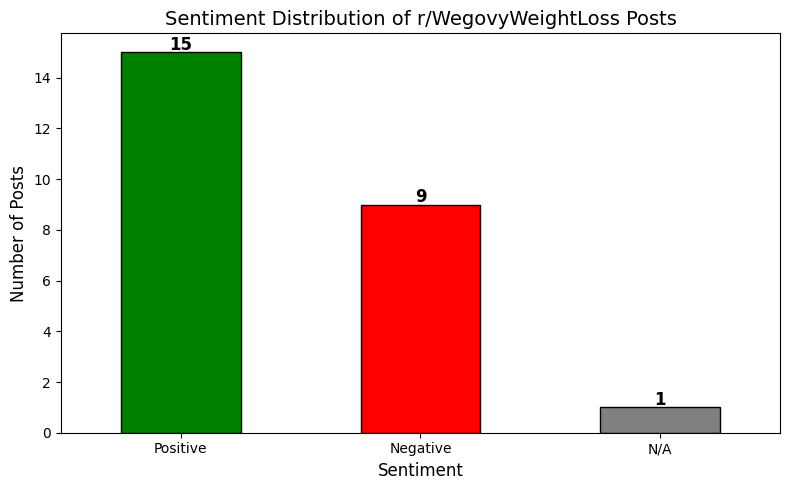

In [13]:
# ── Visualize Sentiment Distribution ────────────────────────────
import matplotlib.pyplot as plt

# Count sentiments
sentiment_counts = df['Sentiment'].value_counts()

# Create a bar chart
plt.figure(figsize=(8, 5))
colors = ['green', 'red', 'gray']
sentiment_counts.plot(kind='bar', color=colors, edgecolor='black')

plt.title('Sentiment Distribution of r/WegovyWeightLoss Posts', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.xticks(rotation=0)

# Add count labels on top of each bar
for i, value in enumerate(sentiment_counts):
    plt.text(i, value + 0.1, str(value), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
pip install wordcloud


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Top 20 Most Common Words:
          Word  Count
0       weight     34
1       people     28
2        still     28
3         food     27
4         some     23
5       wegovy     21
6          day     20
7         time     20
8         dose     20
9   medication     19
10         don     17
11        most     16
12         eat     16
13      eating     15
14       thing     15
15       fiber     15
16        feel     14
17        work     14
18      myself     14
19     started     14


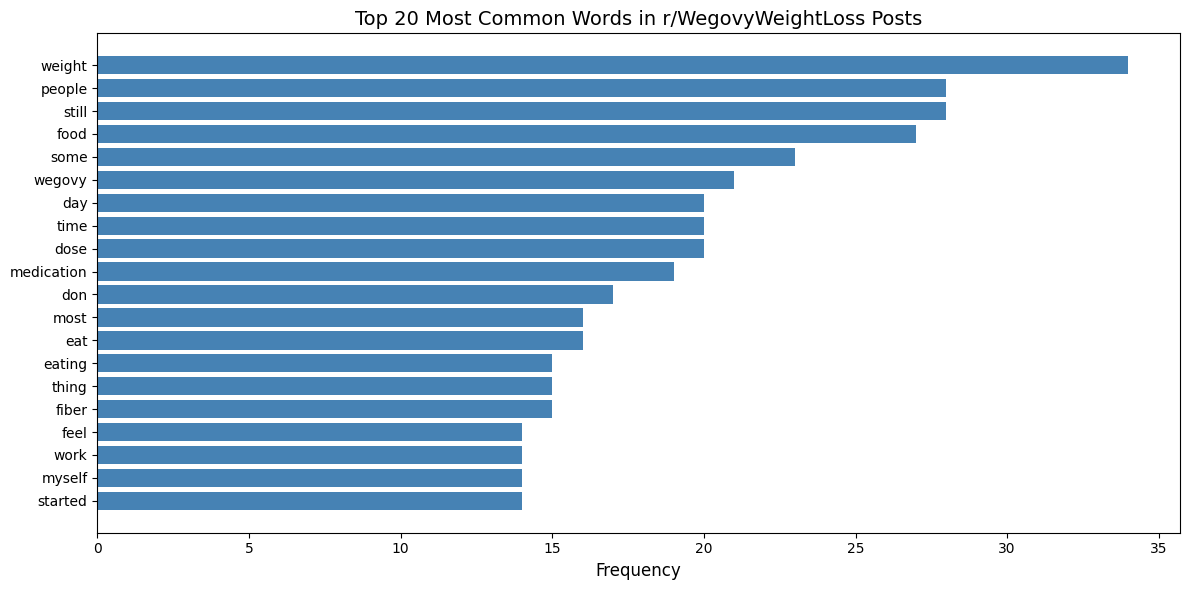

In [15]:
# ── Word Frequency Analysis ──────────────────────────────────────
from collections import Counter
import re

# Common words we want to IGNORE (called "stop words")
# These are words like "the", "a", "I" that don't tell us anything useful
stop_words = set([
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to',
    'for', 'of', 'with', 'i', 'my', 'me', 'it', 'is', 'was', 'be',
    'have', 'has', 'had', 'this', 'that', 'are', 'so', 'just', 'not',
    'do', 'did', 'if', 'up', 'out', 'as', 'by', 'from', 'you', 'your',
    'we', 'they', 'them', 'their', 'its', 'been', 'will', 'can', 'all',
    'about', 'get', 'got', 'more', 'also', 'back', 'one', 'when',
    'what', 'how', 'no', 'now', 'into', 'like', 'over', 'after',
    'previous', 'next', 'view', 'grid', 'he', 'she', 'his', 'her'
])

# Combine all post content into one big string
all_text = ' '.join(df['Content'].dropna().tolist()).lower()

# Remove special characters and numbers, keep only words
words = re.findall(r'\b[a-z]{3,}\b', all_text)

# Remove stop words
filtered_words = [w for w in words if w not in stop_words]

# Count the top 20 most common words
word_counts = Counter(filtered_words).most_common(20)
words_df = pd.DataFrame(word_counts, columns=['Word', 'Count'])

print("Top 20 Most Common Words:")
print(words_df)

# Plot it
plt.figure(figsize=(12, 6))
plt.barh(words_df['Word'][::-1], words_df['Count'][::-1], color='steelblue')
plt.title('Top 20 Most Common Words in r/WegovyWeightLoss Posts', fontsize=14)
plt.xlabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

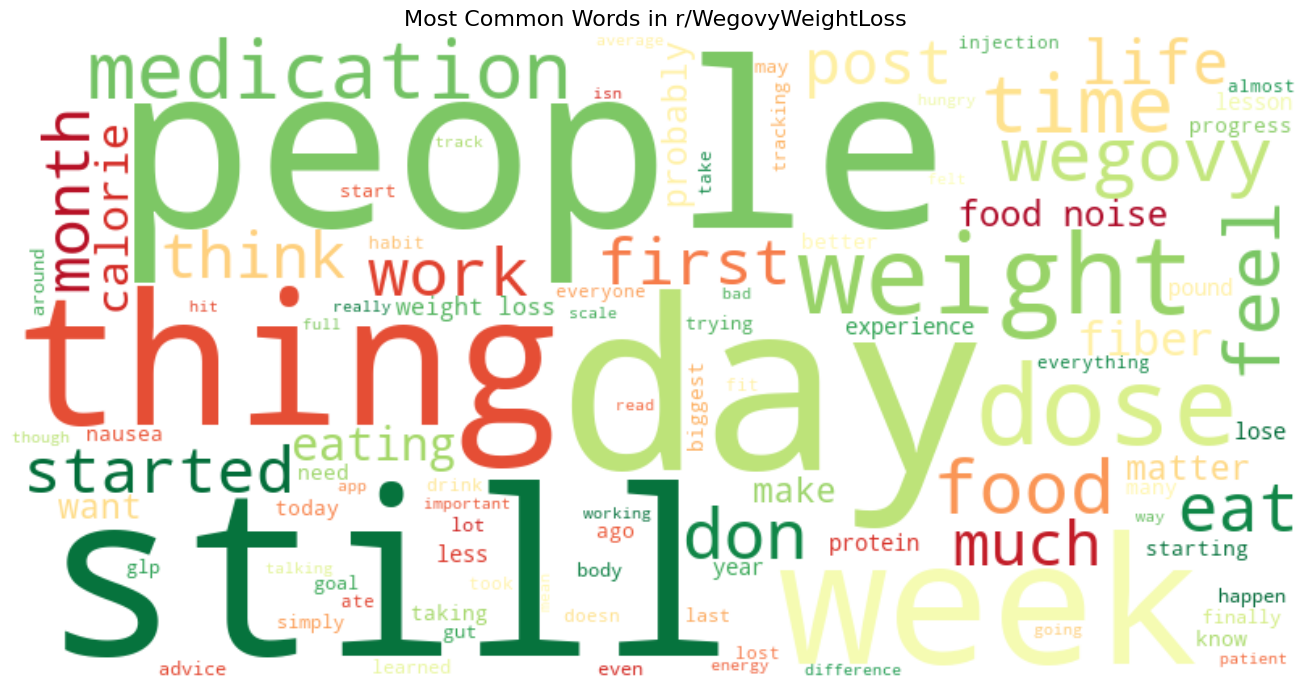

In [16]:

# ── Word Cloud ───────────────────────────────────────────────────
from wordcloud import WordCloud

# Join all filtered words into one string
text_for_cloud = ' '.join(filtered_words)

# Generate the word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='RdYlGn',    # Red = less common, Green = more common
    max_words=100
).generate(text_for_cloud)

# Display it
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in r/WegovyWeightLoss', fontsize=16)
plt.tight_layout()
plt.show()

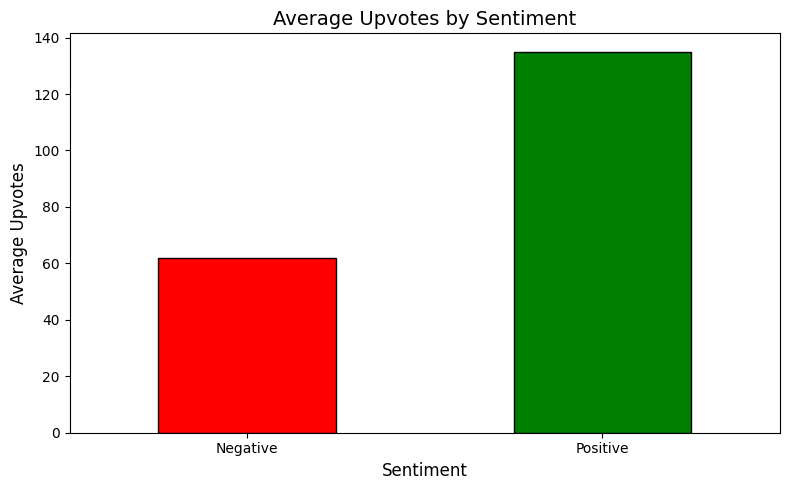

In [17]:
# ── Upvotes vs Sentiment ─────────────────────────────────────────

# Convert upvotes to numbers (some are '·' which means hidden)
df['Upvotes_Clean'] = pd.to_numeric(df['Upvotes'], errors='coerce')

# Group by sentiment and get average upvotes
upvotes_by_sentiment = df.groupby('Sentiment')['Upvotes_Clean'].mean().dropna()

plt.figure(figsize=(8, 5))
colors = {'Positive': 'green', 'Negative': 'red', 'Neutral': 'gray'}
upvotes_by_sentiment.plot(
    kind='bar',
    color=[colors.get(s, 'gray') for s in upvotes_by_sentiment.index],
    edgecolor='black'
)
plt.title('Average Upvotes by Sentiment', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Average Upvotes', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

/var/folders/wv/gydn7dyn4h90yncm1jrf005r0000gn/T/ipykernel_71748/2981727278.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['Month'] = df['Posted Date'].dt.to_period('M')


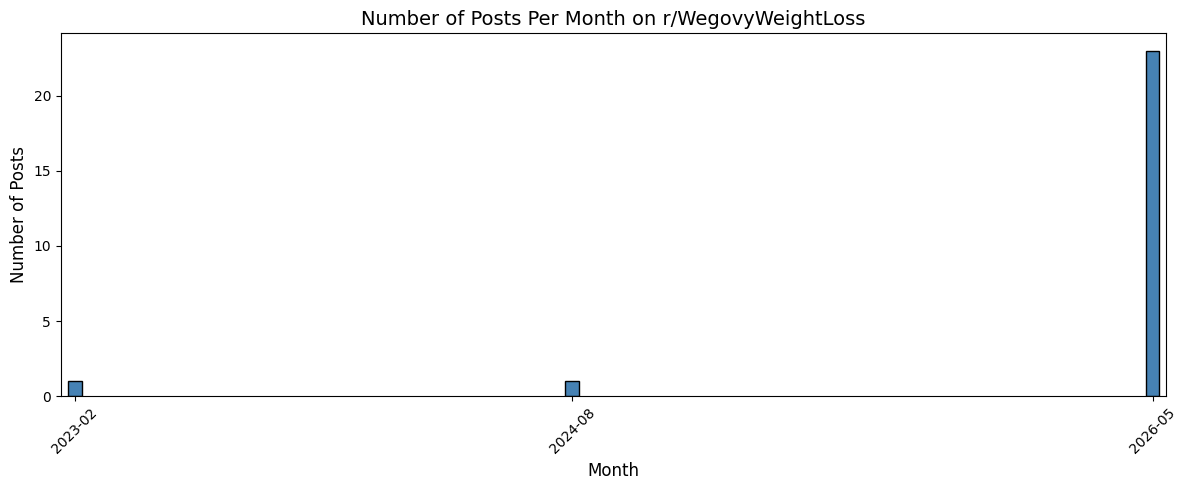

Month
2023-02     1
2024-08     1
2026-05    23
Freq: M, dtype: int64


In [18]:
# ── Posts Over Time ──────────────────────────────────────────────

# Convert Posted Date to datetime format
df['Posted Date'] = pd.to_datetime(df['Posted Date'])

# Extract just the date (no time)
df['Date Only'] = df['Posted Date'].dt.date

# Extract month and year for grouping
df['Month'] = df['Posted Date'].dt.to_period('M')

# Count posts per month
posts_per_month = df.groupby('Month').size()

# Plot
plt.figure(figsize=(12, 5))
posts_per_month.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Posts Per Month on r/WegovyWeightLoss', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(posts_per_month)

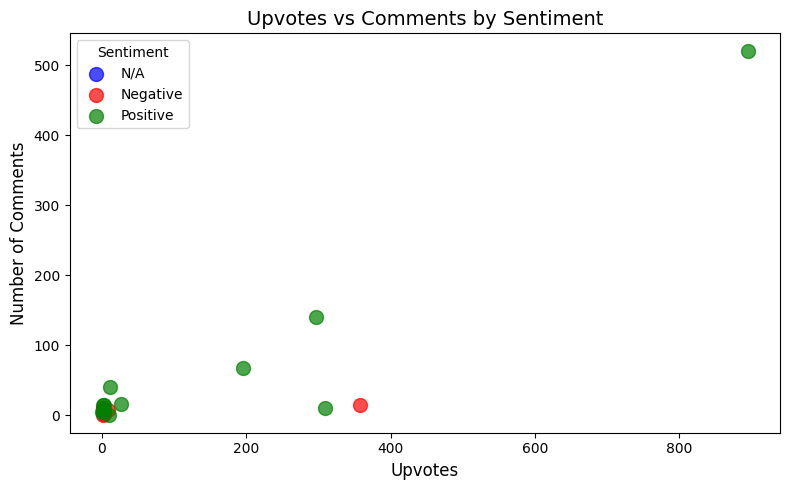

In [19]:
# ── Comments vs Upvotes Scatter Plot ────────────────────────────

# Clean up Comments column to numbers
df['Comments_Clean'] = pd.to_numeric(df['Comments'], errors='coerce')

# Create scatter plot
plt.figure(figsize=(8, 5))
colors_map = {'Positive': 'green', 'Negative': 'red', 'Neutral': 'gray', 'N/A': 'blue'}

for sentiment, group in df.groupby('Sentiment'):
    plt.scatter(
        group['Upvotes_Clean'],
        group['Comments_Clean'],
        label=sentiment,
        color=colors_map.get(sentiment, 'gray'),
        s=100,
        alpha=0.7
    )

plt.title('Upvotes vs Comments by Sentiment', fontsize=14)
plt.xlabel('Upvotes', fontsize=12)
plt.ylabel('Number of Comments', fontsize=12)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()